# Review Notebook – Team Member 2
## MATH1604 Modelling for Big Data – Group Project

This notebook covers my part of the group project. My job was to build the 
data pipeline - basically, writing code that goes online, grabs all the quiz 
answer files, and organises them into one clean file that the rest of the team 
can work with. Below I show the code running, test that it handles errors 
properly, and take a look at whether the quiz answers seem to follow any kind 
of pattern.

In [1]:
import sys
import os

sys.path.insert(0, os.path.join('..', 'scripts'))

from data_preparation_m2 import download_answer_files, collate_answer_files
print("Module imported successfully.")

Module imported successfully.


In [2]:
download_answer_files(
    "https://raw.githubusercontent.com/fc-leeds/MATH1604_2025_2026_data/main",
    os.path.join('..', 'data'),
    64
)
print("Download complete.")

Download complete.


In [3]:
collate_answer_files(os.path.join('..', 'data'))
print("Collation complete.")

Collation complete.


In [4]:
# Check all 64 files were downloaded
data_folder = os.path.join('..', 'data')
files = sorted([f for f in os.listdir(data_folder) if f.startswith('answers_respondent_')])
print(f"Number of files downloaded: {len(files)}")
print(f"First file: {files[0]}")
print(f"Last file:  {files[-1]}")

Number of files downloaded: 64
First file: answers_respondent_1.txt
Last file:  answers_respondent_9.txt


In [5]:
# Check the collated file
collated_path = os.path.join('..', 'output', 'collated_answers.txt')

with open(collated_path, 'r', encoding='utf-8') as f:
    content = f.read()

separator_count = content.count('\n*\n')
print(f"Number of respondent sections: {separator_count + 1}")
print(f"Number of * separators: {separator_count}")
print(f"File size: {len(content):,} characters")
print()
print("--- First 200 characters ---")
print(content[:200])

Number of respondent sections: 64
Number of * separators: 63
File size: 1,377,598 characters

--- First 200 characters ---
Question 1. What is a program?
[X] A set of instructions that tells a computer what to do.
[ ] A computer virus that infects systems.
[ ] A type of computer hardware.
[ ] A kind of programming languag


In [6]:
# Test 1: empty URL should raise ValueError
try:
    download_answer_files('', '../data', 64)
except ValueError as e:
    print(f"Test 1 passed: {e}")

# Test 2: invalid respondent_index should raise ValueError
try:
    download_answer_files('https://example.com', '../data', 0)
except ValueError as e:
    print(f"Test 2 passed: {e}")

# Test 3: missing folder should raise FileNotFoundError
try:
    collate_answer_files('nonexistent_folder')
except FileNotFoundError as e:
    print(f"Test 3 passed: {e}")

# Test 4: requesting more files than exist should raise OSError
try:
    download_answer_files(
        "https://raw.githubusercontent.com/fc-leeds/MATH1604_2025_2026_data/main",
        os.path.join('..', 'data'),
        65
    )
except OSError as e:
    print(f"Test 4 passed: {e}")

Test 1 passed: cloud_url must be a non-empty string.
Test 2 passed: respondent_index must be a positive integer.
Test 3 passed: Data folder does not exist: nonexistent_folder
Test 4 passed: Could not download file from https://raw.githubusercontent.com/fc-leeds/MATH1604_2025_2026_data/main/a65.txt


## Pattern Investigation

Now that the data is ready, I wanted to see if there is anything interesting 
in the answers. The idea is simple - for each of the 100 questions, I look at 
what answer most people picked. If the majority of respondents chose the same 
option for a question, that option is most likely the correct one. Once I have 
the most common answer for each question, I can plot them and see if they form 
any kind of pattern.

In [7]:
from collections import Counter
import matplotlib.pyplot as plt

# Split collated file into individual respondent sections
sections = content.split('\n*\n')
print(f"Sections found: {len(sections)}")

# Find the most common answer for each question
modal_answers = []
for q in range(100):
    responses = []
    for section in sections:
        lines = section.strip().split('\n')
        option = 0
        count = 0
        for line in lines:
            line = line.strip()
            if line.startswith('['):
                count += 1
                if line.startswith('[x]') or line.startswith('[X]'):
                    option = count
        # Only use this respondent's answer for question q
        responses.append(option)
    
# Extract all answers per respondent first (simpler)
def extract_answers(text):
    answers = []
    option_index = 0
    current = 0
    for line in text.strip().split('\n'):
        line = line.strip()
        if line.startswith('Question'):
            if option_index > 0:
                answers.append(current)
            current = 0
            option_index = 0
        elif line.startswith('['):
            option_index += 1
            if line.startswith('[x]') or line.startswith('[X]'):
                current = option_index
    if option_index > 0:
        answers.append(current)
    return answers

all_answers = [extract_answers(s) for s in sections]
valid = [a for a in all_answers if len(a) == 100]
print(f"Respondents with 100 answers: {len(valid)}")

# Find modal answer per question
modal_answers = []
for q in range(100):
    responses = [r[q] for r in valid if r[q] != 0]
    modal_answers.append(Counter(responses).most_common(1)[0][0] if responses else 0)

print(f"\nModal answer sequence (first 20): {modal_answers[:20]}")

Sections found: 64
Respondents with 100 answers: 64

Modal answer sequence (first 20): [1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4]


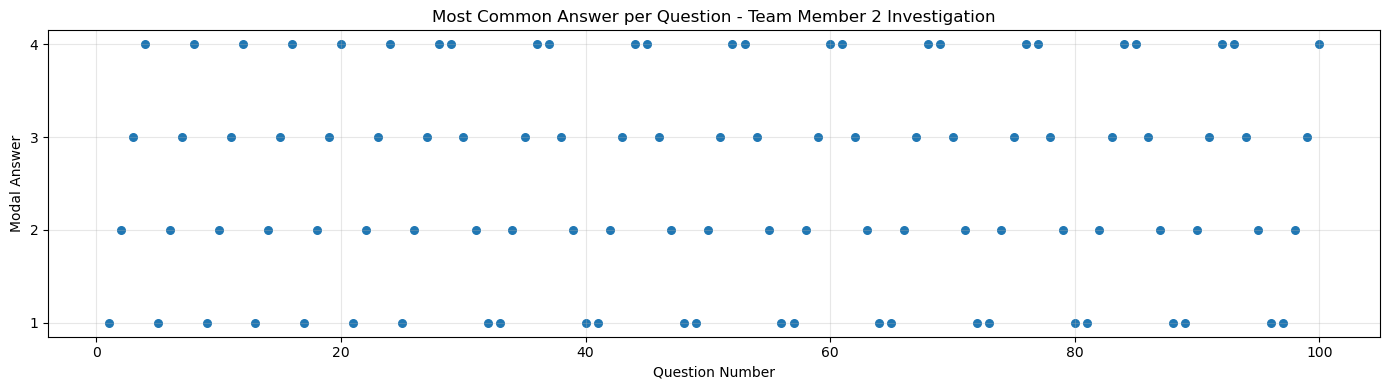

Questions where answer matches 4 positions later: 24/96
This suggests a repeating cycle of length 4: 1, 2, 3, 4


In [8]:
plt.figure(figsize=(14, 4))
plt.scatter(range(1, 101), modal_answers, s=30)
plt.xlabel('Question Number')
plt.ylabel('Modal Answer')
plt.title('Most Common Answer per Question - Team Member 2 Investigation')
plt.yticks([1, 2, 3, 4])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Confirm the cycle
cycle_matches = sum(1 for i in range(96) if modal_answers[i] == modal_answers[i + 4])
print(f"Questions where answer matches 4 positions later: {cycle_matches}/96")
print(f"This suggests a repeating cycle of length 4: 1, 2, 3, 4")

## What I found

Looking at the plot, the pattern is actually pretty obvious. The most common 
answer cycles through 1, 2, 3, 4 and then repeats that all the way from 
question 1 to question 100. It never deviates. This is almost certainly not 
a coincidence, it looks like the quiz setter deliberately arranged the correct 
answers in that order. The dataset I built worked correctly throughout, 
downloading all 64 files and combining them cleanly, which is what allowed 
this pattern to become visible in the first place.